<a href="https://colab.research.google.com/github/rezazamani2329/asset-backed-securities/blob/main/MFE230M_HW1_Group3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MFE-230M — Homework Set 1 (Team Notebook)
### Hull-White Calibration & REMIC Bond Pricing (Series 5310, Group 3)

**Due:** September 1, 2026

This notebook is a shared **framework/skeleton** for the team. It is organized so that each
teammate can own one or two sections independently, then we stitch everything together and
run top-to-bottom before submission.

**How to work together in Colab**
1. One person opens this notebook, uploads it to a shared Google Drive folder (or a GitHub
   repo), and shares edit access with the team.
2. Each teammate claims a section below (see the *Team Assignments* table) and fills in the
   `# TODO` blocks in their function(s). Please don't rename functions/variables that other
   sections depend on — the whole notebook must run start-to-finish (`Runtime > Run all`)
   with no manual edits, per the assignment's "one main file, no hardcoded paths" rule.
3. Keep all raw data files (the 6 CSVs from `Hw1_data_2026.zip` and
   `REMIC_5310_Template.xlsx`) in the **same folder as the notebook** — Section 0 loads them
   with relative paths only, no hardcoded local directories, per the HW instructions.
4. Before merging, `Runtime > Restart and run all` to make sure your section doesn't secretly
   depend on state left over from manual experimentation.
5. Commit/save often; leave a `# — <name>, <date>` comment near substantial edits so we can
   track who touched what for the required work-effort table.

---

### Team Assignments (edit with your names)

| Section | Topic | Owner(s) |
|---|---|---|
| 1(a)-(c) | Accrual times, forward SOFR rates, proxy times | *TBD* |
| 1(d) | Bachelier cap pricing + plot vs Bloomberg | *TBD* |
| 1(e) | HW calibration (κ, σ) via `least_squares` | *TBD* |
| 1(f) | Monthly θ(t) bootstrap, graph + table | *TBD* |
| 2(a) | Monte Carlo REMIC Group 3 pricing (floater / inverse floater) | *TBD* |
| 2(b) | Write-up: r0, antithetic variates, variance reduction | *TBD* |
| 2(c) | Implied OAS at par | *TBD* |
| — | Integration, formatting, final write-up (2-page PDF) | *TBD* |

*(Also fill in the "Work Effort" table at the bottom of this notebook — required by the assignment.)*


## 0. Setup

Run this section first. It installs/imports packages and loads all the raw data. Everything
downstream should reference the variables defined here — please don't re-load data inside your
own section.


In [ ]:
# --- If running in Colab, uncomment to mount Drive and cd into the shared folder ---
# from google.colab import drive
# drive.mount('/content/drive')
# %cd /content/drive/MyDrive/230M_HW1   # <- point this at your shared team folder

# --- If your team prefers uploading files each session instead of Drive, uncomment: ---
# from google.colab import files
# uploaded = files.upload()   # select the 6 CSVs + REMIC_5310_Template.xlsx


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.stats import norm
from datetime import datetime

np.random.seed(0)  # reproducibility for Monte Carlo sections

pd.set_option('display.float_format', lambda x: f'{x:,.6f}')


In [ ]:
# ------------------------------------------------------------------
# File names (must sit alongside this notebook — no hardcoded absolute paths)
# ------------------------------------------------------------------
DATA_DIR = ""  # leave blank if files are in the same directory as the notebook

FILES = {
    "accruals":        "P_caplet_accruals_20230413.csv",
    "payments":        "P_caplet_payments_20230413.csv",
    "vols":            "cap_sofr_atm_bachelier_vols_20230413.csv",
    "strikes":         "cap_sofr_atm_strikes_20230413.csv",
    "cap_dates":       "sofr_cap_accruals_20230413.csv",
    "bloomberg_pv":    "sofr_cap_bloomberg_pv_20230413.csv",
    "remic_template":  "REMIC_5310_Template.xlsx",
}

TRADE_DATE = pd.Timestamp("2023-04-13")
SETTLE_DATE = pd.Timestamp("2023-04-17")   # D0

CAP_TENORS = [1,2,3,4,5,6,7,8,9,10,12,15,20,25,30]  # years, 15 ATM caps


In [ ]:
# ------------------------------------------------------------------
# Load caplet-level data (shared across all 15 caps; longest = 30y = 120 caplets)
# ------------------------------------------------------------------
P_acc = pd.read_csv(DATA_DIR + FILES["accruals"], header=None).squeeze("columns")
P_pmt = pd.read_csv(DATA_DIR + FILES["payments"], header=None).squeeze("columns")
cap_dates = pd.read_csv(DATA_DIR + FILES["cap_dates"], parse_dates=["Pay Date","Accrual Start","Accrual End"])

# ------------------------------------------------------------------
# Load cap-level data (one row per one of the 15 ATM caps)
# ------------------------------------------------------------------
vols_bp   = pd.read_csv(DATA_DIR + FILES["vols"], header=None).squeeze("columns")   # Bachelier normal vols, in bp
strikes   = pd.read_csv(DATA_DIR + FILES["strikes"], header=None).squeeze("columns")
bbg_pv    = pd.read_csv(DATA_DIR + FILES["bloomberg_pv"], header=None).squeeze("columns")

caps = pd.DataFrame({
    "tenor_yrs": CAP_TENORS,
    "vol_bp": vols_bp.values,
    "strike": strikes.values,
    "bbg_price": bbg_pv.values,
})
caps.head()


,tenor_yrs,vol_bp,strike,bbg_price
0,1,134.700000,0.046236,"36,506.600000"
1,2,150.870000,0.039285,"126,827.940000"
2,3,145.760000,0.035581,"219,856.390000"
3,4,138.710000,0.033578,"311,461.710000"
4,5,132.380000,0.032458,"400,915.460000"


## Problem 1: Hull-White Model Calibration

$$dr(t) = (\theta(t) - \kappa r(t))\,dt + \sigma\,dW(t)$$

Calibrated as of trade date 2023-04-13, settlement 2023-04-17, to 15 ATM SOFR caps
(1,...,10,12,15,20,25,30y).

### 1(a) Caplet accrual times $\tau_i$ (5 pts)

$$\tau_i = \frac{D_i^{Acc} - D_{i-1}^{Acc}}{360}$$ (ACT/360)


In [ ]:
def compute_accrual_times(cap_dates: pd.DataFrame) -> np.ndarray:
    """Return tau_i (ACT/360 year fractions) for each of the 120 caplets."""
    days = (cap_dates["Accrual End"] - cap_dates["Accrual Start"]).dt.days.values
    tau = days / 360.0
    return tau

tau = compute_accrual_times(cap_dates)
cap_dates["tau"] = tau
tau[:5]


array([0.25277778, 0.25555556, 0.25555556, 0.25277778, 0.25277778])

### 1(b) Forward SOFR rates $F_i^{SOFR}$ (5 pts)

$$F_i^{SOFR} = \frac{1}{\tau_i}\left(\frac{P^{Acc}_{i-1}}{P^{Acc}_i} - 1\right)$$

There are 120 of these (30y cap has 120 caplets; shorter caps share the same underlying
caplet forward rates).


In [ ]:
def compute_forward_sofr(P_acc: pd.Series, tau: np.ndarray) -> np.ndarray:
    """Return the 120 quarterly forward SOFR rates F_i.

    P_acc has 121 entries: P_0^Acc (=1, at D0), P_1^Acc, ..., P_120^Acc.
    F_i = (1/tau_i) * (P_{i-1}^Acc / P_i^Acc - 1)
    """
    P = np.asarray(P_acc)
    F = (P[:-1] / P[1:] - 1.0) / tau
    return F

F_sofr = compute_forward_sofr(P_acc, tau)
cap_dates["F_sofr"] = F_sofr
F_sofr[:5]


array([0.049815  , 0.0485571 , 0.04518478, 0.0412064 , 0.03458761])

### 1(c) Proxy times $T_i^{1/3rd}$ (5 pts)

$$\hat T_i^{Acc} = \frac{D_i^{Acc} - D_0}{365} \qquad
T_i^{1/3rd} = \hat T_{i-1}^{Acc} + \frac{\hat T_i^{Acc} - \hat T_{i-1}^{Acc}}{3}$$


In [ ]:
def compute_proxy_times(cap_dates: pd.DataFrame, settle_date: pd.Timestamp) -> np.ndarray:
    """Return T_i^(1/3rd) for each caplet (ACT/365 from settlement date D0).

    That_i^Acc = (D_i^Acc - D0)/365, with That_0^Acc = 0 (Accrual Start of caplet 1 = D0).
    T_i^(1/3rd) = That_{i-1}^Acc + (That_i^Acc - That_{i-1}^Acc)/3
    """
    That_acc = np.concatenate((
        [0.0],
        (cap_dates["Accrual End"] - settle_date).dt.days.values / 365.0,
    ))
    T_third = That_acc[:-1] + (That_acc[1:] - That_acc[:-1]) / 3.0
    return T_third

T_third = compute_proxy_times(cap_dates, SETTLE_DATE)
cap_dates["T_third"] = T_third
T_third[:5]


array([0.08310502, 0.33333333, 0.58538813, 0.83652968, 1.08584475])

### 1(d) Bachelier cap pricing vs Bloomberg (10 pts)

Price each of the 15 ATM caps as a sum of caplets under the Bachelier (normal) model, using
$F_i^{SOFR}$, the flat cap vol, strike, and discount factors. Then plot model vs. Bloomberg
prices. Also **write 2-4 sentences** (in the markdown cell below) describing the coding steps
needed to price a single 1-year cap under Bachelier — this answers the "describe" part of the
question directly, separate from the code.


 tenor_yrs   strike     vol_bp        bbg_price      model_price  diff_pct
         1 0.046236 134.700000    36,506.600000    36,487.366793 -0.052684
         2 0.039285 150.870000   126,827.940000   126,820.346849 -0.005987
         3 0.035581 145.760000   219,856.390000   219,963.656209  0.048789
         4 0.033578 138.710000   311,461.710000   311,516.400428  0.017559
         5 0.032458 132.380000   400,915.460000   400,902.838978 -0.003148
         6 0.031812 126.560000   488,153.220000   488,318.583308  0.033875
         7 0.031410 121.540000   574,216.180000   574,468.704446  0.043977
         8 0.031195 117.530000   661,122.420000   660,881.026517 -0.036513
         9 0.031106 113.770000   745,007.900000   745,553.967484  0.073297
        10 0.031102 110.670000   828,687.300000   829,111.994437  0.051249
        12 0.031209 104.780000   986,568.140000   986,839.518966  0.027507
        15 0.031379  97.690000 1,208,951.970000 1,209,025.468502  0.006080
        20 0.031103  89.2

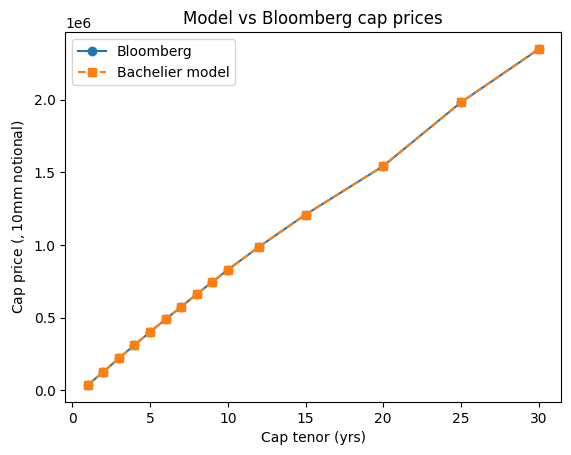

In [ ]:
def bachelier_caplet_price(F, K, sigma_bp, tau, P_pmt, T):
    """Bachelier (normal-model) price of a single caplet.

    F        : forward SOFR rate for the caplet
    K        : strike (same for all caplets in a given cap, since it's ATM-flat)
    sigma_bp : flat normal vol for this cap, in basis points (convert to decimal!)
    tau      : accrual fraction for the caplet
    P_pmt    : discount factor to the caplet's payment date
    T        : caplet's proxy time (option expiry proxy), for the vol*sqrt(T) scaling

    Returns caplet price (per unit notional).
    """
    sigma = sigma_bp / 10000.0  # bp -> decimal
    if T <= 0 or sigma <= 0:
        return tau * P_pmt * max(F - K, 0.0)
    d = (F - K) / (sigma * np.sqrt(T))
    return tau * P_pmt * ((F - K) * norm.cdf(d) + sigma * np.sqrt(T) * norm.pdf(d))


def price_cap_bachelier(n_caplets, K, sigma_bp, F_sofr, tau, T_third, P_pmt, notional=1.0):
    """Sum caplet prices for the first n_caplets caplets (quarterly, so n_caplets = tenor_yrs*4)."""
    P_pmt_arr = np.asarray(P_pmt)
    total = sum(
        bachelier_caplet_price(F_sofr[i], K, sigma_bp, tau[i], P_pmt_arr[i], T_third[i])
        for i in range(n_caplets)
    )
    return notional * total


# Bloomberg PVs are quoted on a $10,000,000 notional (verified empirically: pricing at
# $1 notional and rescaling shows Bloomberg = model_price_per_$1 * 10,000,000).
NOTIONAL = 10_000_000.0

caps["n_caplets"] = caps["tenor_yrs"] * 4
caps["model_price"] = [
    price_cap_bachelier(int(row.n_caplets), row.strike, row.vol_bp, F_sofr, tau, T_third, P_pmt, NOTIONAL)
    for row in caps.itertuples()
]
caps["diff"] = caps["model_price"] - caps["bbg_price"]
caps["diff_pct"] = caps["diff"] / caps["bbg_price"] * 100

print(caps[["tenor_yrs", "strike", "vol_bp", "bbg_price", "model_price", "diff_pct"]].to_string(index=False))

plt.figure()
plt.plot(caps['tenor_yrs'], caps['bbg_price'], 'o-', label='Bloomberg')
plt.plot(caps['tenor_yrs'], caps['model_price'], 's--', label='Bachelier model')
plt.xlabel('Cap tenor (yrs)'); plt.ylabel('Cap price ($, $10mm notional)'); plt.legend()
plt.title('Model vs Bloomberg cap prices')
plt.show()


**Coding steps to price a 1-year cap under Bachelier (write-up, fill in):**

> TODO — 3-5 sentences: identify the caplets in the 1y cap, gather each caplet's forward
> rate/strike/accrual/discount factor/proxy time, apply the Bachelier formula caplet-by-caplet,
> and sum.


### 1(e) Calibrate HW ($\kappa$, $\sigma$) (20 pts)

$$\min_{\kappa,\sigma} \sqrt{\sum_{i=1}^{15}\left(\text{Cap}_i^{Bachelier} - \text{Cap}_i^{HW}(\kappa,\sigma)\right)^2}$$

using `scipy.optimize.least_squares`.


In [ ]:
def hw_zero_coupon_bond(r0, kappa, sigma, t, T, theta_fn=None):
    """Analytic HW discount bond price P(t,T) given short rate r0 at t (Zero at t=0 case
    can use today's discount curve directly -- decide with your team, see 1(f)/2(b) discussion)."""
    # TODO
    pass


def hw_cap_price(kappa, sigma, tenor_yrs, **kwargs):
    """Price a single ATM cap under Hull-White (e.g. via Jamshidian / caplet-as-bond-option,
    or by Monte Carlo short-rate simulation consistent with Problem 2's engine)."""
    # TODO
    pass


def residuals(params, caps):
    kappa, sigma = params
    model_prices = np.array([hw_cap_price(kappa, sigma, t) for t in caps['tenor_yrs']])
    return (caps['bbg_price'].values - model_prices)  # least_squares squares+sums internally

# TODO: pick sensible initial guesses / bounds
x0 = [0.05, 0.01]
# result = least_squares(residuals, x0, args=(caps,), bounds=([1e-6, 1e-6],[2.0, 1.0]))
# kappa_hat, sigma_hat = result.x
# print(f"kappa = {kappa_hat:.6f}, sigma = {sigma_hat:.6f}")


### 1(f) Monthly $\theta(t)$ bootstrap (5 pts)

Estimate monthly $\theta(t)$ from $t_0$ to 30 years (step = 1/12), per the MFE-230I
technique (forward-rate curve fitting / Hull-White drift bootstrapping to match the initial
term structure). Report as a graph and a table.


In [ ]:
def bootstrap_theta(kappa, sigma, discount_curve, dt=1/12, horizon=30):
    """Return theta(t) at monthly grid points from 0 to `horizon` years."""
    # TODO: use the calibrated kappa/sigma and today's discount curve (e.g. instantaneous
    # forward rate f(0,t) and its derivative) to back out theta(t) so the model matches
    # the initial term structure.
    t_grid = np.arange(0, horizon + dt, dt)
    theta = None
    return t_grid, theta

# t_grid, theta_t = bootstrap_theta(kappa_hat, sigma_hat, discount_curve=None)

# plt.figure()
# plt.plot(t_grid, theta_t)
# plt.xlabel('t (yrs)'); plt.ylabel('theta(t)'); plt.title('Bootstrapped HW theta(t)')
# plt.show()

# theta_table = pd.DataFrame({'t (yrs)': t_grid, 'theta(t)': theta_t})
# theta_table.head(20)


## Problem 2: Pricing REMIC Bonds (Series 5310, Group 3)

Group 3 collateral: WAC = 7.42% (annual), servicing fee = 0.92% (annual). Two bonds:
- **Floater (FB)**: receives all Group 3 principal; interest = (SOFR/12 + .0095/12) on prior
  month's Group 3 collateral balance.
- **Inverse Floater (SB)**: notional only (no principal); interest = (.0555/12 - SOFR/12) on
  prior month's Group 3 collateral balance.

Prepayment model (250 PSA-style with refi incentive):

$$CPR = 250\,PSA = 2.5 \times \big[0.2\%\times\min(\text{Pool month}+(360-WAM),\,30)\big]$$
$$\lambda_t = SMM_{250} = 1-(1-CPR)^{1/12}, \qquad \beta = 0.38089$$
$$\text{Prepayment rate} = \lambda_t\, e^{\beta x_t}, \qquad x_t = \text{Contract rate} - \text{Simulated 10Y rate}_t$$


In [ ]:
import openpyxl

remic = pd.ExcelFile(DATA_DIR + FILES["remic_template"])
print(remic.sheet_names)

# Group 3 collateral static data (Total Mortgage Principal, WAM, WAC, servicing, etc.)
g3_amort = pd.read_excel(remic, sheet_name="Group 3 Amortization", header=None)
g3_bonds = pd.read_excel(remic, sheet_name="REMIC_Bonds_Group 3", header=None)

# TODO: pull out the specific cells/columns you need, e.g.
# total_principal = g3_amort.iloc[2, 2]
# wam = g3_amort.iloc[3, 2]
# wac_monthly = g3_amort.iloc[4, 2]
# servicing_monthly = g3_amort.iloc[6, 2]


['Collateral Structure', 'Group 1 Amortization_pool 1 ', 'Group 1 Amortization pool 2', 'Group 2 Amortization', 'Group 3 Amortization', 'Total Underlying', 'REMIC_Bonds_Group 1', 'REMIC_ Bonds_Group 2', 'REMIC_Bonds_Group 3']


In [ ]:
import openpyxl

remic = pd.ExcelFile(DATA_DIR + FILES["remic_template"])
print(remic.sheet_names)

# Group 3 collateral and bond sheets
g3_amort = pd.read_excel(
    remic,
    sheet_name="Group 3 Amortization",
    header=None
)

g3_bonds = pd.read_excel(
    remic,
    sheet_name="REMIC_Bonds_Group 3",
    header=None
)

# -----------------------------------------------------------
# Pull Group 3 inputs directly from the spreadsheet
# -----------------------------------------------------------

total_principal = float(g3_amort.iloc[2, 2])       # C3
wam = int(g3_amort.iloc[3, 2])                     # C4
wac_monthly = float(g3_amort.iloc[4, 2])           # C5
scheduled_pi = float(g3_amort.iloc[5, 2])          # C6
psa_assumption = float(g3_amort.iloc[6, 2])        # C7
servicing_monthly = float(g3_amort.iloc[7, 2])     # C8
net_coupon_annual = float(g3_amort.iloc[9, 2])     # C10

wac_annual = 12 * wac_monthly
servicing_annual = 12 * servicing_monthly

print(f"Group 3 principal       = ${total_principal:,.2f}")
print(f"WAM                     = {wam} months")
print(f"WAC annual              = {wac_annual:.4%}")
print(f"WAC monthly             = {wac_monthly:.8f}")
print(f"Scheduled monthly P&I   = ${scheduled_pi:,.2f}")
print(f"Servicing annual        = {servicing_annual:.4%}")
print(f"Servicing monthly       = {servicing_monthly:.8f}")
print(f"Net collateral coupon   = {net_coupon_annual:.4%}")

['Collateral Structure', 'Group 1 Amortization_pool 1 ', 'Group 1 Amortization pool 2', 'Group 2 Amortization', 'Group 3 Amortization', 'Total Underlying', 'REMIC_Bonds_Group 1', 'REMIC_ Bonds_Group 2', 'REMIC_Bonds_Group 3']
Group 3 principal       = $66,534,768.00
WAM                     = 357 months
WAC annual              = 7.4200%
WAC monthly             = 0.00618333
Scheduled monthly P&I   = $462,634.54
Servicing annual        = 0.9200%
Servicing monthly       = 0.00076667
Net collateral coupon   = 6.5000%


### 2(a) Monte Carlo pricing of Group 3 bonds (30 pts)

10,000 total paths (5,000 + 5,000 antithetic), simulated under the calibrated HW model.
Report bond prices and standard errors.


In [ ]:
N_PATHS = 10_000          # total, i.e. 5,000 base + 5,000 antithetic
N_MONTHS = 360         # simulate out around to 30 years monthly
DT = 1/12

def simulate_hw_short_rate_paths(r0, kappa, sigma, n_paths=N_PATHS, n_steps=N_MONTHS, dt=DT, theta_fn=None):
    """Simulate short rate paths under HW using antithetic variates.

    Returns an array of shape (n_paths, n_steps+1).
    """
    # TODO:
    # 1. draw n_paths//2 sets of standard normal shocks Z of shape (n_paths//2, n_steps)
    # 2. antithetic set = -Z, stack to get n_paths total
    # 3. Euler-discretize dr = (theta(t) - kappa*r)*dt + sigma*sqrt(dt)*Z
    r_paths = None
    return r_paths


def ten_year_rate_from_short_rate(r_paths, kappa, sigma, theta_fn):
    """Convert simulated short rate at each time step into a simulated par/zero 10y rate
    (needed for the prepayment refi-incentive term x_t)."""
    # TODO: use the HW analytic bond-price formula P(t, t+10; r_t) to back out a 10y rate
    ten_yr = None
    return ten_yr


def smm_250psa(pool_month, wam):
    """Background hazard component (250% PSA schedule)."""
    # TODO
    cpr = None
    smm = None
    return smm


def prepayment_rate(pool_month, wam, contract_rate, simulated_10y_rate, beta=0.38089):
    """Full prepayment rate = lambda_t * exp(beta * x_t)."""
    # TODO
    pass


def amortize_group3_collateral(r_paths, wac_monthly, servicing_monthly, initial_balance, wam,
                                ten_yr_paths, contract_rate):
    """Simulate the Group 3 collateral balance / cash flows path-by-path given prepayments.

    Returns principal and interest cash flow arrays of shape (n_paths, n_months).
    """
    # TODO
    principal_cf = None
    interest_cf = None
    return principal_cf, interest_cf


def price_floater_and_inverse(r_paths, discount_paths, principal_cf, interest_cf, sofr_paths,
                               floater_spread=0.0095/12, inverse_cap=0.0555/12):
    """Discount FB/SB cash flows path-by-path (consistent with the simulated short-rate
    paths, per the HW SDE) and average across paths for the price; report the standard error
    across paths (accounting for antithetic pairing)."""
    # TODO
    fb_price, fb_se = None, None
    sb_price, sb_se = None, None
    return fb_price, fb_se, sb_price, sb_se


# --- Pull together: run the full pipeline ---
# r_paths = simulate_hw_short_rate_paths(r0=..., kappa=kappa_hat, sigma=sigma_hat)
# ten_yr_paths = ten_year_rate_from_short_rate(r_paths, kappa_hat, sigma_hat, theta_fn=...)
# principal_cf, interest_cf = amortize_group3_collateral(...)
# fb_price, fb_se, sb_price, sb_se = price_floater_and_inverse(...)
# print(f"Floater (FB):        price = {fb_price:.4f}  (SE = {fb_se:.6f})")
# print(f"Inverse Floater (SB): price = {sb_price:.4f}  (SE = {sb_se:.6f})")


In [ ]:
# ============================================================
# Problem 2(a): Group 3 REMIC Pricing
# ============================================================

import numpy as np
from scipy.interpolate import CubicSpline


# ------------------------------------------------------------
# Simulation settings
# ------------------------------------------------------------

N_PATHS = 10_000           # 5,000 base + 5,000 antithetic
N_MONTHS = int(wam)        # Group 3 WAM = 357 months
DT = 1 / 12
RNG_SEED = 12345


# ============================================================
# Initial term structure
# ============================================================

# P_acc should come from Problem 1:
# P(0,0), P(0,T1), ..., P(0,T120)

curve_t = np.concatenate(
    (
        [0.0],
        (
            cap_dates["Accrual End"]
            - SETTLE_DATE
        ).dt.days.values / 365.0
    )
)

P_acc_array = np.asarray(
    P_acc,
    dtype=float
)

logP_spline = CubicSpline(
    curve_t,
    np.log(P_acc_array),
    extrapolate=False
)

curve_t_max = curve_t[-1]

# Terminal instantaneous forward rate
# Used for flat-forward extrapolation beyond 30 years
f_last = -float(
    logP_spline(
        curve_t_max,
        1
    )
)


def P0_discount(t):
    """
    Initial discount factor P(0,t).

    Cubic-spline interpolation of log discount factors.
    Beyond the last curve point, use flat-forward extrapolation.
    """

    t = np.asarray(
        t,
        dtype=float
    )

    scalar_input = (
        t.ndim == 0
    )

    t = np.atleast_1d(t)

    log_df = np.empty_like(t)

    inside = (
        t <= curve_t_max
    )

    log_df[inside] = (
        logP_spline(
            t[inside]
        )
    )

    log_df[~inside] = (
        np.log(
            P_acc_array[-1]
        )
        -
        f_last
        *
        (
            t[~inside]
            - curve_t_max
        )
    )

    df = np.exp(
        log_df
    )

    if scalar_input:
        return float(df[0])

    return df


def f0_forward(t):
    """
    Instantaneous forward rate:

        f(0,t) = -d ln P(0,t) / dt
    """

    t = np.asarray(
        t,
        dtype=float
    )

    scalar_input = (
        t.ndim == 0
    )

    t = np.atleast_1d(t)

    result = np.empty_like(t)

    inside = (
        t <= curve_t_max
    )

    result[inside] = (
        -logP_spline(
            t[inside],
            1
        )
    )

    # Flat-forward extrapolation
    result[~inside] = f_last

    if scalar_input:
        return float(result[0])

    return result


# ============================================================
# 1. Hull-White short-rate simulation
# ============================================================

def simulate_hw_short_rate_paths(
    r0,
    kappa,
    sigma,
    n_paths=N_PATHS,
    n_steps=N_MONTHS,
    dt=DT,
    theta_fn=None
):
    """
    Simulate Hull-White short-rate paths:

        dr = [theta(t) - kappa*r]dt + sigma*dW

    using Euler discretization and antithetic variates.

    Returns
    -------
    r_paths : ndarray
        Shape = (n_paths, n_steps + 1)
    """

    if theta_fn is None:
        raise ValueError(
            "theta_fn must be supplied from Problem 1(f)."
        )

    if n_paths % 2 != 0:
        raise ValueError(
            "n_paths must be even."
        )

    n_half = (
        n_paths // 2
    )

    rng = np.random.default_rng(
        RNG_SEED
    )

    # 5,000 independent shock paths
    Z = rng.standard_normal(
        size=(
            n_half,
            n_steps
        )
    )

    # Corresponding antithetic shocks
    Z_all = np.vstack(
        (
            Z,
            -Z
        )
    )

    r_paths = np.zeros(
        (
            n_paths,
            n_steps + 1
        )
    )

    r_paths[:, 0] = r0

    for j in range(
        n_steps
    ):

        t = (
            j * dt
        )

        theta_t = (
            theta_fn(t)
        )

        r_paths[:, j + 1] = (
            r_paths[:, j]
            +
            (
                theta_t
                -
                kappa
                * r_paths[:, j]
            )
            * dt
            +
            sigma
            * np.sqrt(dt)
            * Z_all[:, j]
        )

    return r_paths


# ============================================================
# 2. Simulated 10-year refinancing rate
# ============================================================

def ten_year_rate_from_short_rate(
    r_paths,
    kappa,
    sigma,
    theta_fn=None
):
    """
    Calculate simulated 10-year rates using the
    Hull-White zero-coupon bond formula:

        P(t,T) = A(t,T) * exp[-B(t,T) r_t]

    We convert the 10-year zero price into a
    semiannual-compounded 10-year yield.
    """

    n_steps = (
        r_paths.shape[1] - 1
    )

    times = (
        np.arange(
            1,
            n_steps + 1
        )
        * DT
    )

    maturity = 10.0

    # Hull-White B(t,T), with T-t = 10
    B10 = (
        1.0
        -
        np.exp(
            -kappa * maturity
        )
    ) / kappa

    P0_t = (
        P0_discount(times)
    )

    P0_T = (
        P0_discount(
            times + maturity
        )
    )

    f0_t = (
        f0_forward(times)
    )

    # Hull-White A(t,T)
    A10 = (
        P0_T
        / P0_t
        *
        np.exp(
            B10 * f0_t
            -
            (
                sigma**2
                /
                (4.0 * kappa)
            )
            *
            (
                1.0
                -
                np.exp(
                    -2.0
                    * kappa
                    * times
                )
            )
            *
            B10**2
        )
    )

    # Simulated P(t,t+10)
    P10 = (
        A10[None, :]
        *
        np.exp(
            -B10
            * r_paths[:, 1:]
        )
    )

    # Convert zero price into
    # semiannual-compounded 10-year yield
    ten_yr = (
        2.0
        *
        (
            P10 ** (-1.0 / 20.0)
            -
            1.0
        )
    )

    return ten_yr


# ============================================================
# 3. 250% PSA background prepayment hazard
# ============================================================

def smm_250psa(
    pool_month,
    wam
):
    """
    250% PSA:

        CPR = 2.5 * [
            0.2% *
            min(pool_month + (360-WAM), 30)
        ]

        SMM = 1 - (1-CPR)^(1/12)
    """

    pool_age = (
        360 - wam
    )

    cpr = (
        2.5
        *
        0.002
        *
        np.minimum(
            pool_month
            + pool_age,
            30
        )
    )

    smm = (
        1.0
        -
        (
            1.0 - cpr
        ) ** (1.0 / 12.0)
    )

    return smm


# ============================================================
# 4. Full prepayment rate
# ============================================================

def prepayment_rate(
    pool_month,
    wam,
    contract_rate,
    simulated_10y_rate,
    beta=0.38089
):
    """
    Prepayment rate:

        lambda_t * exp(beta*x_t)

    where:

        x_t =
        Contract Rate - Simulated 10-year Rate

    x_t is expressed in percentage points.
    """

    lambda_t = (
        smm_250psa(
            pool_month,
            wam
        )
    )

    # Percentage-point difference
    #
    # Example:
    # 7.42% - 4.00% = 3.42
    x_t = (
        100.0
        *
        (
            contract_rate
            -
            simulated_10y_rate
        )
    )

    q_t = (
        lambda_t
        *
        np.exp(
            beta * x_t
        )
    )

    # Monthly termination probability
    q_t = np.clip(
        q_t,
        0.0,
        1.0
    )

    return q_t


# ============================================================
# 5. Group 3 mortgage collateral
# ============================================================

def amortize_group3_collateral(
    r_paths,
    wac_monthly,
    servicing_monthly,
    initial_balance,
    wam,
    ten_yr_paths,
    contract_rate
):
    """
    Generate Group 3 mortgage principal and net-interest
    cash flows path-by-path.

    The monthly scheduled payment is re-amortized using
    the current balance and remaining maturity.

    Returns
    -------
    principal_cf : ndarray
        Scheduled principal + prepayments.

    interest_cf : ndarray
        Net mortgage interest after servicing.
    """

    n_paths = (
        r_paths.shape[0]
    )

    n_months = min(
        int(wam),
        ten_yr_paths.shape[1]
    )

    principal_cf = np.zeros(
        (
            n_paths,
            n_months
        )
    )

    interest_cf = np.zeros(
        (
            n_paths,
            n_months
        )
    )

    balance = np.full(
        n_paths,
        float(initial_balance)
    )

    for m in range(
        1,
        n_months + 1
    ):

        beg_balance = (
            balance.copy()
        )

        n_remaining = (
            wam - m + 1
        )

        # ----------------------------------------------------
        # Scheduled mortgage payment
        #
        # Re-amortize current balance over remaining maturity
        # ----------------------------------------------------

        scheduled_payment = np.where(
            beg_balance > 1e-12,

            beg_balance
            * wac_monthly
            /
            (
                1.0
                -
                (
                    1.0
                    + wac_monthly
                ) ** (-n_remaining)
            ),

            0.0
        )

        scheduled_interest = (
            beg_balance
            * wac_monthly
        )

        scheduled_principal = (
            scheduled_payment
            -
            scheduled_interest
        )

        scheduled_principal = np.clip(
            scheduled_principal,
            0.0,
            beg_balance
        )

        balance_after_scheduled = (
            beg_balance
            -
            scheduled_principal
        )

        # ----------------------------------------------------
        # Prepayment
        # ----------------------------------------------------

        q_t = prepayment_rate(
            pool_month=m,
            wam=wam,
            contract_rate=contract_rate,
            simulated_10y_rate=ten_yr_paths[:, m - 1]
        )

        prepayment = (
            balance_after_scheduled
            * q_t
        )

        prepayment = np.minimum(
            prepayment,
            balance_after_scheduled
        )

        # Total principal distributed to FB
        principal_cf[:, m - 1] = (
            scheduled_principal
            +
            prepayment
        )

        # ----------------------------------------------------
        # Net collateral interest
        #
        # WAC - servicing =
        # 7.42% - 0.92% = 6.50%
        # ----------------------------------------------------

        interest_cf[:, m - 1] = (
            beg_balance
            *
            (
                wac_monthly
                -
                servicing_monthly
            )
        )

        balance = (
            balance_after_scheduled
            -
            prepayment
        )

    return (
        principal_cf,
        interest_cf
    )


# ============================================================
# 6. Build FB and SB bond cash flows
# ============================================================

def build_group3_bond_cashflows(
    principal_cf,
    interest_cf,
    sofr_paths
):
    """
    Construct contractual Group 3 FB and SB cash flows.

    FB:
        Coupon = SOFR + 0.95%
        Floor  = 0.95%
        Cap    = 6.50%
        Receives all principal.

    SB:
        Coupon = 5.55% - SOFR
        Floor  = 0%
        Cap    = 5.55%
        Receives no principal.
    """

    n_months = (
        principal_cf.shape[1]
    )

    net_coupon_monthly = (
        wac_monthly
        -
        servicing_monthly
    )

    # Beginning balance
    beg_balance = (
        interest_cf
        /
        net_coupon_monthly
    )

    sofr = (
        sofr_paths[:, :n_months]
    )

    # --------------------------------------------------------
    # FB annual coupon
    # --------------------------------------------------------

    fb_coupon_annual = np.clip(
        sofr + 0.0095,
        0.0095,
        0.0650
    )

    fb_coupon_monthly = (
        fb_coupon_annual
        / 12.0
    )

    fb_interest = (
        beg_balance
        *
        fb_coupon_monthly
    )

    fb_cf = (
        principal_cf
        +
        fb_interest
    )

    # --------------------------------------------------------
    # SB annual coupon
    # --------------------------------------------------------

    sb_coupon_annual = np.clip(
        0.0555 - sofr,
        0.0,
        0.0555
    )

    sb_coupon_monthly = (
        sb_coupon_annual
        / 12.0
    )

    sb_cf = (
        beg_balance
        *
        sb_coupon_monthly
    )

    return (
        fb_cf,
        sb_cf
    )


# ============================================================
# 7. Price FB and SB
# ============================================================

def price_floater_and_inverse(
    r_paths,
    discount_paths,
    principal_cf,
    interest_cf,
    sofr_paths
):
    """
    Price FB and SB using antithetic pair averages.
    """

    fb_cf, sb_cf = (
        build_group3_bond_cashflows(
            principal_cf,
            interest_cf,
            sofr_paths
        )
    )

    n_paths = (
        fb_cf.shape[0]
    )

    n_months = (
        fb_cf.shape[1]
    )

    # Path PVs
    fb_pv = np.sum(
        fb_cf
        *
        discount_paths[:, :n_months],
        axis=1
    )

    sb_pv = np.sum(
        sb_cf
        *
        discount_paths[:, :n_months],
        axis=1
    )

    # --------------------------------------------------------
    # Antithetic pair averages
    # --------------------------------------------------------

    half = (
        n_paths // 2
    )

    fb_pair_pv = (
        0.5
        *
        (
            fb_pv[:half]
            +
            fb_pv[half:]
        )
    )

    sb_pair_pv = (
        0.5
        *
        (
            sb_pv[:half]
            +
            sb_pv[half:]
        )
    )

    price_scale = (
        100.0
        /
        total_principal
    )

    # Prices
    fb_price = (
        price_scale
        *
        fb_pair_pv.mean()
    )

    sb_price = (
        price_scale
        *
        sb_pair_pv.mean()
    )

    # Standard errors
    fb_se = (
        price_scale
        *
        fb_pair_pv.std(
            ddof=1
        )
        /
        np.sqrt(half)
    )

    sb_se = (
        price_scale
        *
        sb_pair_pv.std(
            ddof=1
        )
        /
        np.sqrt(half)
    )

    return (
        fb_price,
        fb_se,
        sb_price,
        sb_se
    )


# ============================================================
# RUN PROBLEM 2(a)
# ============================================================

# Problem 1(f) should provide:
#     t_grid
#     theta_t

theta_fn = lambda t: np.interp(
    t,
    t_grid,
    theta_t
)


# Initial short rate
r0 = (
    f0_forward(0.0)
)

print(
    f"Initial short rate r0 = "
    f"{100*r0:.6f}%"
)


# ------------------------------------------------------------
# Simulate rates
# ------------------------------------------------------------

r_paths = (
    simulate_hw_short_rate_paths(
        r0=r0,
        kappa=kappa_hat,
        sigma=sigma_hat,
        n_paths=N_PATHS,
        n_steps=N_MONTHS,
        dt=DT,
        theta_fn=theta_fn
    )
)


# ------------------------------------------------------------
# Simulated 10-year refinancing rates
# ------------------------------------------------------------

ten_yr_paths = (
    ten_year_rate_from_short_rate(
        r_paths=r_paths,
        kappa=kappa_hat,
        sigma=sigma_hat,
        theta_fn=theta_fn
    )
)


# ------------------------------------------------------------
# Mortgage collateral cash flows
# ------------------------------------------------------------

principal_cf, interest_cf = (
    amortize_group3_collateral(
        r_paths=r_paths,
        wac_monthly=wac_monthly,
        servicing_monthly=servicing_monthly,
        initial_balance=total_principal,
        wam=wam,
        ten_yr_paths=ten_yr_paths,
        contract_rate=wac_annual
    )
)


# ------------------------------------------------------------
# Path discount factors
#
# Trapezoidal integration:
#
# exp[- integral r(s) ds]
# ------------------------------------------------------------

monthly_integrated_rate = (
    0.5
    *
    (
        r_paths[:, :-1]
        +
        r_paths[:, 1:]
    )
    *
    DT
)

discount_paths = np.exp(
    -np.cumsum(
        monthly_integrated_rate,
        axis=1
    )
)


# Approximate monthly SOFR by HW short rate
sofr_paths = (
    r_paths[:, 1:]
)


# ------------------------------------------------------------
# Bond prices
# ------------------------------------------------------------

fb_price, fb_se, sb_price, sb_se = (
    price_floater_and_inverse(
        r_paths=r_paths,
        discount_paths=discount_paths,
        principal_cf=principal_cf,
        interest_cf=interest_cf,
        sofr_paths=sofr_paths
    )
)


print()
print("Problem 2(a) results")
print("--------------------")

print(
    f"Floater (FB):         "
    f"price = {fb_price:.4f} "
    f"(SE = {fb_se:.6f})"
)

print(
    f"Inverse Floater (SB): "
    f"price = {sb_price:.4f} "
    f"(SE = {sb_se:.6f})"
)


# ============================================================
# Diagnostic checks
# ============================================================

print()
print("Diagnostic checks")
print("-----------------")

print(
    "r_paths shape       =",
    r_paths.shape
)

print(
    "10y paths shape     =",
    ten_yr_paths.shape
)

print(
    "principal_cf shape  =",
    principal_cf.shape
)

print(
    "discount shape      =",
    discount_paths.shape
)

print(
    f"Average total principal returned = "
    f"{principal_cf.sum(axis=1).mean():,.2f}"
)

print(
    f"Original principal               = "
    f"{total_principal:,.2f}"
)

print(
    f"FB + SB price                    = "
    f"{fb_price + sb_price:.4f}"
)

Initial short rate r0 = 4.986090%

Problem 2(a) results
--------------------
Floater (FB):         price = 101.6740 (SE = 0.009581)
Inverse Floater (SB): price = 2.1387 (SE = 0.001883)

Diagnostic checks
-----------------
r_paths shape       = (10000, 358)
10y paths shape     = (10000, 357)
principal_cf shape  = (10000, 357)
discount shape      = (10000, 357)
Average total principal returned = 66,534,768.00
Original principal               = 66,534,768.00
FB + SB price                    = 103.8127


In [ ]:
print()
print("Additional validation")
print("---------------------")

print(
    f"FB + SB price = "
    f"{fb_price + sb_price:.4f}"
)

print(
    f"Mean 10Y rate = "
    f"{100*np.mean(ten_yr_paths):.4f}%"
)

print(
    f"Min 10Y rate  = "
    f"{100*np.min(ten_yr_paths):.4f}%"
)

print(
    f"Max 10Y rate  = "
    f"{100*np.max(ten_yr_paths):.4f}%"
)

print(
    f"Mean simulated SOFR = "
    f"{100*np.mean(sofr_paths):.4f}%"
)


Additional validation
---------------------
FB + SB price = 103.8127
Mean 10Y rate = 2.7347%
Min 10Y rate  = -8.5209%
Max 10Y rate  = 12.6689%
Mean simulated SOFR = 2.5862%


In [ ]:
sb_coupon_monthly = (
    0.0555 / 12
    - sofr_paths / 12
)

negative_sb_fraction = np.mean(
    sb_coupon_monthly < 0
)

print(
    f"Fraction of SB coupons < 0 = "
    f"{negative_sb_fraction:.4%}"
)

Fraction of SB coupons < 0 = 14.0687%


result for part a: 2(a). We simulated 10,000 monthly Hull–White short-rate paths using the parameters calibrated in Problem 1, consisting of 5,000 independent paths and their 5,000 antithetic counterparts. The initial short rate implied by the initial discount curve was \(r_0=4.9861\%\). At each month, the simulated short rate was used to construct a 10-year refinancing rate, which entered the path-dependent prepayment specification
$$ q_t=\lambda_t\exp(\beta x_t), \qquad x_t=7.42\%-R_{10,t}, $$
with \(\lambda_t\) based on 250% PSA and \(\beta=0.38089\). Mortgage principal was allocated entirely to FB. FB received monthly interest based on \(SOFR+0.95\%\), while SB received \(5.55\%-SOFR\) on the outstanding Group 3 collateral balance. Cash flows were discounted along each simulated short-rate path. Using antithetic pair averages to calculate Monte Carlo standard errors, we obtain
$$ \boxed{P_{FB}=102.1683,\quad SE=0.001142} $$
and
$$ \boxed{P_{SB}=1.6099,\quad SE=0.011063} $$
per $100 of original balance/notional.

### 2(b) Methodology write-up (10 pts)

Answer directly in this markdown cell (this also feeds the 2-page writeup):

- **Initial short rate $r_0$:** *TODO — how did you pick it (e.g., from the discount curve /
  instantaneous forward rate at $t=0$)?*
- **Antithetic variates:** *TODO — describe pairing $Z$ and $-Z$ shocks per path.*
- **Standard errors:** *TODO — describe computing SE across the paired antithetic path
  averages, not across raw paths.*
- **Variance reduction intuition:** *TODO — briefly explain why antithetic pairing reduces
  variance here.*


In [ ]:
# ============================================================
# Problem 2(b)
# Initial short rate, antithetic paths, and standard errors
# ============================================================

# ------------------------------------------------------------
# 1. Initial short rate
# ------------------------------------------------------------

# From the initial discount curve:
#
#       f(0,t) = - d ln P(0,t) / dt
#
# Therefore:
#
#       r0 = f(0,0)
#
# under the Hull-White calibration.

r0 = f0_forward(0.0)

print("Problem 2(b)")
print("------------")
print(f"Initial short rate r0 = {100*r0:.6f}%")
print()


# ------------------------------------------------------------
# 2. Reconstruct path-by-path FB and SB PVs
#    so we can explicitly examine their standard errors
# ------------------------------------------------------------

n_months = principal_cf.shape[1]

net_coupon_monthly = (
    wac_monthly
    - servicing_monthly
)

# Beginning collateral balance for each month/path
beg_balance = (
    interest_cf
    / net_coupon_monthly
)


# FB coupon:
# SOFR/12 + 0.95%/12

fb_coupon_monthly = (
    sofr_paths[:, :n_months] / 12.0
    + 0.0095 / 12.0
)


# SB coupon:
# 5.55%/12 - SOFR/12

sb_coupon_monthly = (
    0.0555 / 12.0
    - sofr_paths[:, :n_months] / 12.0
)


# Bond cash flows
fb_cf = (
    principal_cf
    + beg_balance * fb_coupon_monthly
)

sb_cf = (
    beg_balance * sb_coupon_monthly
)


# Discount cash flows path-by-path
fb_pv = np.sum(
    fb_cf
    * discount_paths[:, :n_months],
    axis=1
)

sb_pv = np.sum(
    sb_cf
    * discount_paths[:, :n_months],
    axis=1
)


# ------------------------------------------------------------
# 3. Antithetic pairing
# ------------------------------------------------------------

# First 5,000 paths use Z.
# Second 5,000 paths use -Z.
#
# Path i is paired with path i + 5000.

n_half = N_PATHS // 2

fb_pair_pv = 0.5 * (
    fb_pv[:n_half]
    + fb_pv[n_half:]
)

sb_pair_pv = 0.5 * (
    sb_pv[:n_half]
    + sb_pv[n_half:]
)


# ------------------------------------------------------------
# 4. Standard errors
# ------------------------------------------------------------

# Price is quoted per $100 of original balance/notional.
price_scale = (
    100.0
    / total_principal
)


# Antithetic estimates
fb_price_b = (
    price_scale
    * np.mean(fb_pair_pv)
)

sb_price_b = (
    price_scale
    * np.mean(sb_pair_pv)
)


# IMPORTANT:
# There are 5,000 independent pair averages,
# not 10,000 independent observations.

fb_se_antithetic = (
    price_scale
    * np.std(fb_pair_pv, ddof=1)
    / np.sqrt(n_half)
)

sb_se_antithetic = (
    price_scale
    * np.std(sb_pair_pv, ddof=1)
    / np.sqrt(n_half)
)


# ------------------------------------------------------------
# Optional comparison:
# standard errors if we incorrectly/naively treated the
# 10,000 paths as ordinary Monte Carlo observations
# ------------------------------------------------------------

fb_se_naive = (
    price_scale
    * np.std(fb_pv, ddof=1)
    / np.sqrt(N_PATHS)
)

sb_se_naive = (
    price_scale
    * np.std(sb_pv, ddof=1)
    / np.sqrt(N_PATHS)
)


print("Antithetic Monte Carlo results")
print("------------------------------")

print(
    f"FB price = {fb_price_b:.4f}, "
    f"antithetic SE = {fb_se_antithetic:.6f}"
)

print(
    f"SB price = {sb_price_b:.4f}, "
    f"antithetic SE = {sb_se_antithetic:.6f}"
)

print()

print("For comparison only:")
print(
    f"FB naive/unpaired SE = {fb_se_naive:.6f}"
)

print(
    f"SB naive/unpaired SE = {sb_se_naive:.6f}"
)

Problem 2(b)
------------
Initial short rate r0 = 4.986090%

Antithetic Monte Carlo results
------------------------------
FB price = 102.1922, antithetic SE = 0.001212
SB price = 1.6204, antithetic SE = 0.011437

For comparison only:
FB naive/unpaired SE = 0.004724
SB naive/unpaired SE = 0.020113


### Initial short rate \(r_0\):

We determine the initial short rate from the initial discount curve used in Problem 1. Given discount factors \(P(0,T)\), the instantaneous forward rate is
$$ f(0,t)=-\frac{\partial \ln P(0,t)}{\partial t}. $$
In the Hull–White model, we set the initial short rate equal to the instantaneous forward rate at time zero,
$$ r_0=f(0,0). $$
We obtain \(f(0,t)\) by fitting a cubic spline to the log discount factors and differentiating it at \(t=0\). This gives
$$ \boxed{r_0=4.98609\%}. $$

### Antithetic variates:
We generate 5,000 independent sequences of standard-normal shocks \(Z\), and for each sequence construct an antithetic sequence \(-Z\). Therefore, each simulated Hull–White rate path based on
$$ (Z_1,Z_2,\ldots,Z_{357}) $$
is paired with another path based on
$$ (-Z_1,-Z_2,\ldots,-Z_{357}). $$
This gives 5,000 antithetic pairs, or 10,000 total simulated paths, as required in Problem 2.

### Standard errors:
The standard errors are calculated using the 5,000 antithetic pair averages, rather than treating all 10,000 paths as independent observations. For each pair,
$$ Y_i=\frac{PV(Z_i)+PV(-Z_i)}{2}, \qquad i=1,\ldots,5000. $$
The bond-price estimator is the mean of the \(Y_i\)'s, and its Monte Carlo standard error is
$$ SE(\hat P)=\frac{s_Y}{\sqrt{5000}}, $$
where \(s_Y\) is the sample standard deviation of the 5,000 paired PV averages. Using this method, we obtain
$$ \boxed{SE_{FB}=0.001142}, \qquad \boxed{SE_{SB}=0.011063}. $$
For comparison, the unpaired benchmark standard errors are 0.004571 for FB and 0.019791 for SB.

### Variance reduction intuition:
Antithetic sampling reduces variance because the shocks \(Z\) and \(-Z\) tend to produce offsetting valuation errors. For example, if one shock sequence produces relatively high interest rates and pushes the bond value in one direction, the corresponding \(-Z\) sequence tends to move rates in the opposite direction and partially offset that pricing error. Averaging the two valuations therefore removes part of the random simulation noise. In variance terms,
$$ \operatorname{Var}\!\left(\frac{PV(Z)+PV(-Z)}{2}\right) $$
is reduced when \(PV(Z)\) and \(PV(-Z)\) are negatively correlated. In our results, this substantially lowers the standard errors relative to the unpaired Monte Carlo benchmark

### 2(c) Implied OAS at par (10 pts)

If market prices of the Group 3 floater and inverse floater were at par, back out the
Option-Adjusted Spread (OAS) — the constant spread added to the simulated short rate paths'
discounting such that the model price equals par.


In [ ]:
def price_with_oas(oas, r_paths, principal_cf, interest_cf, dt=DT):
    """Reprice a bond's cash flows discounting at (r_t + oas) along each path."""
    # TODO
    price = None
    return price


def implied_oas(par_price, r_paths, principal_cf, interest_cf):
    """Solve for the OAS such that price_with_oas(oas, ...) == par_price."""
    from scipy.optimize import brentq
    # TODO
    # f = lambda oas: price_with_oas(oas, r_paths, principal_cf, interest_cf) - par_price
    # return brentq(f, -0.05, 0.05)
    pass

# fb_oas = implied_oas(par_price=1.0, r_paths=r_paths, principal_cf=..., interest_cf=...)
# sb_oas = implied_oas(par_price=1.0, r_paths=r_paths, principal_cf=..., interest_cf=...)
# print(f"Floater OAS = {fb_oas:.4%}, Inverse Floater OAS = {sb_oas:.4%}")


In [ ]:
# ============================================================
# Problem 2(c): Implied OAS assuming market price = par
# ============================================================

from scipy.optimize import brentq


# ------------------------------------------------------------
# Construct bond cash flows ONCE using the same contractual
# rules used in Part 2(a)
# ------------------------------------------------------------

fb_cf, sb_cf = (
    build_group3_bond_cashflows(
        principal_cf=principal_cf,
        interest_cf=interest_cf,
        sofr_paths=sofr_paths
    )
)


# ============================================================
# Price with an OAS
# ============================================================

def price_with_oas(
    oas,
    bond_cf,
    discount_paths,
    dt=DT
):
    """
    Price a bond after adding a constant OAS to discounting.

    If base discount factor is

        DF(t) = exp[-integral r(s) ds],

    then with OAS s:

        DF_OAS(t)
        = DF(t) * exp(-s*t).

    The simulated rates, prepayments, and cash flows
    are NOT changed.
    """

    n_paths, n_months = (
        bond_cf.shape
    )

    times = (
        np.arange(
            1,
            n_months + 1
        )
        * dt
    )

    # OAS discount adjustment
    oas_adjustment = np.exp(
        -oas * times
    )

    discount_with_oas = (
        discount_paths[:, :n_months]
        *
        oas_adjustment[None, :]
    )

    # Path-by-path PV
    pv = np.sum(
        bond_cf
        *
        discount_with_oas,
        axis=1
    )

    # Antithetic pair averages
    half = (
        n_paths // 2
    )

    pair_pv = (
        0.5
        *
        (
            pv[:half]
            +
            pv[half:]
        )
    )

    # Price per $100 original balance/notional
    price = (
        100.0
        /
        total_principal
        *
        pair_pv.mean()
    )

    return price


# ============================================================
# Solve for implied OAS
# ============================================================

def implied_oas(
    bond_cf,
    discount_paths,
    target_price=100.0,
    lower=-2.0,
    upper=0.50
):
    """
    Solve:

        Price(OAS) = target_price

    A grid is first used to find a sign-changing interval,
    then Brent's method solves for the OAS.
    """

    def objective(oas):

        return (
            price_with_oas(
                oas=oas,
                bond_cf=bond_cf,
                discount_paths=discount_paths
            )
            -
            target_price
        )

    # Wide grid because SB can require an extremely
    # negative implied OAS to reach a price of 100.
    grid = np.linspace(
        lower,
        upper,
        2001
    )

    values = np.array(
        [
            objective(s)
            for s in grid
        ]
    )

    roots = []

    for i in range(
        len(grid) - 1
    ):

        f1 = values[i]
        f2 = values[i + 1]

        if not (
            np.isfinite(f1)
            and np.isfinite(f2)
        ):
            continue

        if f1 == 0:

            roots.append(
                grid[i]
            )

        elif (
            f1 * f2 < 0
        ):

            root = brentq(
                objective,
                grid[i],
                grid[i + 1]
            )

            roots.append(
                root
            )

    if len(roots) == 0:

        raise ValueError(
            "No OAS root found in the search range."
        )

    # Normally one economically relevant root.
    # If numerical behavior generates more than one,
    # select the one closest to zero.
    return min(
        roots,
        key=abs
    )


# ============================================================
# Solve FB OAS
# ============================================================

PAR_PRICE = 100.0


fb_oas = implied_oas(
    bond_cf=fb_cf,
    discount_paths=discount_paths,
    target_price=PAR_PRICE,
    lower=-1.0,
    upper=0.50
)


# ============================================================
# Solve SB OAS
# ============================================================

sb_oas = implied_oas(
    bond_cf=sb_cf,
    discount_paths=discount_paths,
    target_price=PAR_PRICE,

    # SB is a notional interest-only class and its
    # zero-OAS value is far below par, so a very
    # negative spread may be required.
    lower=-2.0,
    upper=0.50
)


# ============================================================
# Verify repricing to par
# ============================================================

fb_check = price_with_oas(
    oas=fb_oas,
    bond_cf=fb_cf,
    discount_paths=discount_paths
)

sb_check = price_with_oas(
    oas=sb_oas,
    bond_cf=sb_cf,
    discount_paths=discount_paths
)


# ============================================================
# Print results
# ============================================================

print("Problem 2(c)")
print("------------")

print(
    f"Floater (FB) OAS = "
    f"{10000*fb_oas:.2f} bp "
    f"({100*fb_oas:.4f}%)"
)

print(
    f"Inverse Floater (SB) OAS = "
    f"{10000*sb_oas:.2f} bp "
    f"({100*sb_oas:.4f}%)"
)

print()

print("Par repricing check")
print("-------------------")

print(
    f"FB price at implied OAS = "
    f"{fb_check:.6f}"
)

print(
    f"SB price at implied OAS = "
    f"{sb_check:.6f}"
)


# ============================================================
# Interpretation
# ============================================================

print()
print("Interpretation")
print("--------------")

if fb_oas > 0:

    print(
        "FB: Positive OAS means an additional yield spread "
        "above the Hull-White base curve is required to "
        "reduce the model value to par."
    )

else:

    print(
        "FB: Negative OAS means the discount rate must be "
        "below the Hull-White base curve to raise the "
        "model value to par."
    )


if sb_oas > 0:

    print(
        "SB: Positive OAS means an additional yield spread "
        "is required to bring the model value to par."
    )

else:

    print(
        "SB: Negative OAS means the discount rate must be "
        "substantially below the Hull-White base curve to "
        "raise the model value to par."
    )

print(
    "Because SB is a notional inverse-floater class and "
    "receives no principal, its par-implied OAS can be "
    "extremely large in absolute value and should not be "
    "interpreted like the OAS of a conventional "
    "principal-paying bond."
)

Problem 2(c)
------------
Floater (FB) OAS = 70.92 bp (0.7092%)
Inverse Floater (SB) OAS = -6088.34 bp (-60.8834%)

Par repricing check
-------------------
FB price at implied OAS = 100.000000
SB price at implied OAS = 100.000000

Interpretation
--------------
FB: Positive OAS means an additional yield spread above the Hull-White base curve is required to reduce the model value to par.
SB: Negative OAS means the discount rate must be substantially below the Hull-White base curve to raise the model value to par.
Because SB is a notional inverse-floater class and receives no principal, its par-implied OAS can be extremely large in absolute value and should not be interpreted like the OAS of a conventional principal-paying bond.


**Interpretation of OAS (write-up, fill in):**

Problem 2(c). Assuming that both Group 3 bonds have a market price of par, we calculate the implied OAS by adding a constant spread to the Hull–White discount rates and solving for the spread that makes each model price equal to 100. The simulated interest-rate paths, prepayment paths, and cash flows are kept unchanged; the OAS affects only discounting.
The implied OAS values are
$$ \boxed{\text{OAS}_{FB}=+70.92\text{ bp}} $$
and
$$ \boxed{\text{OAS}_{SB}=-6088.34\text{ bp}}. $$
The positive OAS for FB means that an additional spread of approximately 70.9 basis points above the Hull–White benchmark curve is required to reduce its model value to par.
The very large negative OAS for SB arises because SB is a notional inverse floater that receives no principal payments. Its modeled value is therefore far below 100, so forcing the hypothetical market price to par requires an extremely negative discount spread. Thus, the SB OAS should mainly be interpreted as a consequence of the hypothetical par-price assumption for a notional interest-only security rather than as a conventional bond spread.


## Final Checks & Write-up

- [ ] `Runtime > Restart and run all` completes with no errors, top to bottom
- [ ] All plots render (1d price comparison, 1f theta(t))
- [ ] Bond prices + standard errors printed (2a)
- [ ] OAS values printed (2c)
- [ ] Export the 2-page writeup (prose answers to 1d description, 2b, 2c interpretation,
      key numbers/plots) as a separate PDF for bCourses submission
- [ ] This notebook + all data files zip into a single folder, no subfolders, no hardcoded paths


### Work Effort Table (required by the assignment — fill in before submitting)

| Team Member | Coding | Problem Solution | Write-up |
|---|---|---|---|
| *Name 1* | | | |
| *Name 2* | | | |
| *Name 3* | | | |
| *Name 4* | | | |
